# Lesson 3 — Relationships: correlation & the regression line

*Part 1 · Lesson 3 of 20  ·  data: Ames housing*

**←** [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  [Lesson 4: Where data comes from: sampling & study design](04-where-data-comes-from.ipynb) **→**

**Same idea, another way:**  [Another dataset →](03-relationships-regression~another-dataset.ipynb)  ·  [The code behind it →](03-relationships-regression~the-code.ipynb)

So far we've described **one** variable at a time. The real fun starts with **two**: do bigger
houses cost more? Do penguins with longer bills have deeper bills? In this lesson we'll learn to
*see* a relationship in a **scatterplot**, summarize its straight-line trend with the **correlation
r**, and then draw the single best line through the cloud — the **least-squares regression line** —
so we can make predictions and read off "how much does y change per unit of x."

We'll also meet two famous traps: **correlation is not causation**, and the mind-bending
**Simpson's paradox**, where a trend that points *down* for everyone combined secretly points *up*
inside every group. Run each grey cell with **Shift+Enter**, then tinker.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
sl.use_course_style()

AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
PENGUINS_URL = 'https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv'

ames = sl.load_csv('ames.csv', url=AMES_URL)
penguins = sl.load_csv('penguins.csv', url=PENGUINS_URL)

# Keep only the rows whose measurements we'll actually use (drop the missing ones).
ames = ames.dropna(subset=['area', 'price'])
penguins = penguins.dropna(subset=['bill_length_mm', 'bill_depth_mm', 'species'])

print(f'{len(ames):,} homes (Ames, Iowa)')
print(f'{len(penguins)} penguins (Palmer Station, Antarctica)')
ames[['area', 'price']].head()

2,930 homes (Ames, Iowa)
342 penguins (Palmer Station, Antarctica)


,area,price
0,1656,215000
1,896,105000
2,1329,172000
3,2110,244000
4,1629,189900


## 1) The first move: a scatterplot

When you have **two numbers** for each item — here a home's living `area` (sq ft) and its sale
`price` (dollars) — the picture to draw is a **scatterplot**: one dot per home, $x$ across, $y$ up.
Your eyes do the first analysis for free. Ask three questions of any scatter:

- **Direction** — does $y$ tend to rise with $x$ (positive) or fall (negative)?
- **Form** — is the trend roughly a **straight line**, or curved?
- **Strength** — do the dots hug a line tightly, or scatter into a fuzzy blob?

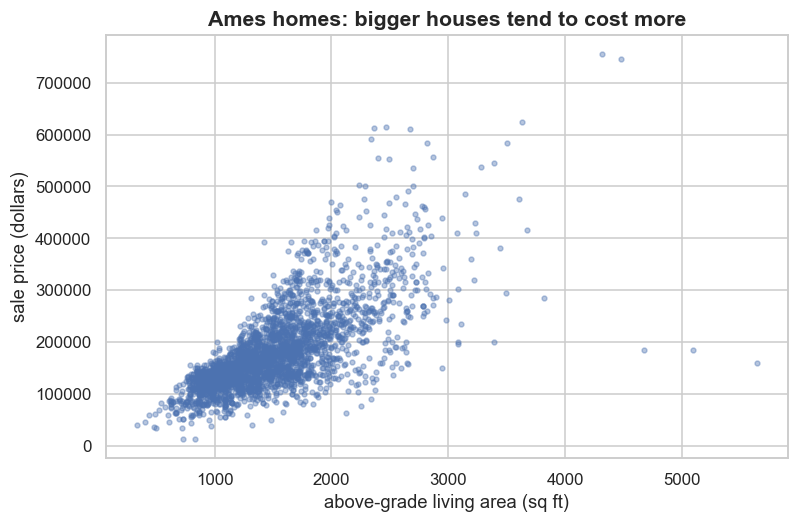

In [2]:
fig, ax = plt.subplots()
ax.scatter(ames['area'], ames['price'], s=10, alpha=0.4, color='#4c72b0')
ax.set_xlabel('above-grade living area (sq ft)')
ax.set_ylabel('sale price (dollars)')
ax.set_title('Ames homes: bigger houses tend to cost more')
plt.show()

Direction: clearly **up**. Form: roughly a **straight line** (with a bit of fanning-out at the high
end). Strength: a fairly tight upward band. That's exactly the situation a single number was invented
to summarize.

## 2) The correlation coefficient r — strength + direction of a *linear* trend

You met $r$ briefly in Lesson 1. Let's deepen it. The correlation $r$ is the average product of the
two variables' **z-scores** (each value rewritten as "how many SDs from its own mean"):

$$r = \frac{1}{n-1}\sum_{i=1}^{n} \left(\frac{x_i-\bar{x}}{s_x}\right)\left(\frac{y_i-\bar{y}}{s_y}\right)$$

- **The math:** standardize both variables, multiply the paired z-scores, average them.
- **The meaning:** when big-$x$ dots are also big-$y$ dots (both z-scores positive) the products pile
  up positive, so $r > 0$; when big-$x$ goes with small-$y$, the products are negative, so $r < 0$.
- **The interpretation:** $r$ runs from $-1$ to $+1$. It measures the **strength and direction of a
  straight-line trend** — $+1$ a perfect upward line, $0$ no linear trend, $-1$ a perfect downward
  line. Because it's built from z-scores, $r$ is **unitless** (changing sq ft to sq metres, or dollars
  to euros, wouldn't budge it) and **symmetric**: the correlation of area-with-price equals the
  correlation of price-with-area.

In [3]:
r = ames['area'].corr(ames['price'])
print(f'correlation r (area, price) = {r:.3f}')
print(f'correlation r (price, area) = {ames["price"].corr(ames["area"]):.3f}   <- same: r is symmetric')

# r is unitless: rescaling either variable leaves it unchanged.
r_metres = (ames['area'] * 0.0929).corr(ames['price'])   # sq ft -> sq metres
print(f'correlation after converting area to sq metres = {r_metres:.3f}   <- unchanged')

correlation r (area, price) = 0.707
correlation r (price, area) = 0.707   <- same: r is symmetric
correlation after converting area to sq metres = 0.707   <- unchanged


An $r$ of about $0.71$ is a **strong, positive** linear relationship — big houses really do go with
big prices, and the dots hug an upward line reasonably tightly.

> **Watch out:** $r$ only sees **straight-line** trends. A perfect U-shape (a strong *curved*
> relationship) can have $r \approx 0$. A small $r$ means "no *linear* trend," **not** "no relationship."
> Always look at the scatter first.

## 3) The least-squares regression line

A summary number is nice, but we'd like an actual **line** so we can predict price from area. We fit

$$\hat{y} = b_0 + b_1 x$$

where $\hat{y}$ (read "y-hat") is the **predicted** price, $b_1$ is the **slope**, and $b_0$ is the
**intercept**. Of all possible lines, the **least-squares** line is the one that makes the total
*squared* vertical miss as small as possible — it minimizes $\sum (y_i - \hat{y}_i)^2$. Its slope and
intercept have tidy formulas:

$$b_1 = r\,\frac{s_y}{s_x}, \qquad b_0 = \bar{y} - b_1\,\bar{x}.$$

The slope formula is worth savoring: it's just the correlation **rescaled** from "per SD" back into
real units (dollars per sq ft). And the intercept formula guarantees the line passes through the
point of averages $(\bar{x}, \bar{y})$.

In [4]:
x = ames['area'].to_numpy()
y = ames['price'].to_numpy()

# Way 1 — straight from the formula b1 = r * (s_y / s_x):
sx, sy = x.std(ddof=1), y.std(ddof=1)
b1_formula = r * (sy / sx)
b0_formula = y.mean() - b1_formula * x.mean()
print(f'from the formula:   slope b1 = {b1_formula:.2f}   intercept b0 = {b0_formula:,.0f}')

# Way 2 — let numpy fit it (and scipy, which also hands back r):
b1_np, b0_np = np.polyfit(x, y, 1)          # returns [slope, intercept]
fit = stats.linregress(x, y)
print(f'from np.polyfit:    slope b1 = {b1_np:.2f}   intercept b0 = {b0_np:,.0f}')
print(f'from linregress:    slope b1 = {fit.slope:.2f}   intercept b0 = {fit.intercept:,.0f}   r = {fit.rvalue:.3f}')

from the formula:   slope b1 = 111.69   intercept b0 = 13,290
from np.polyfit:    slope b1 = 111.69   intercept b0 = 13,290
from linregress:    slope b1 = 111.69   intercept b0 = 13,290   r = 0.707


All three agree (that's the point — the formula *is* what the libraries compute). Now draw the line
over the cloud.

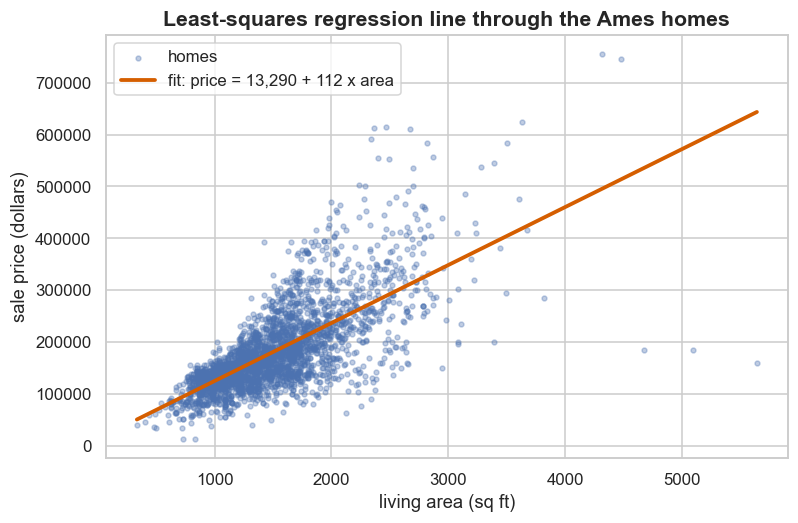

In [5]:
b1, b0 = fit.slope, fit.intercept
line_x = np.array([x.min(), x.max()])
line_y = b0 + b1 * line_x

fig, ax = plt.subplots()
ax.scatter(x, y, s=10, alpha=0.35, color='#4c72b0', label='homes')
ax.plot(line_x, line_y, color='#D55E00', lw=2.5,
        label=f'fit: price = {b0:,.0f} + {b1:.0f} x area')
ax.set_xlabel('living area (sq ft)'); ax.set_ylabel('sale price (dollars)')
ax.set_title('Least-squares regression line through the Ames homes')
ax.legend(); plt.show()

### Interpreting the slope and the intercept

- **Slope $b_1 \approx 112$:** each **extra square foot** of living area is associated with about
  **112 more dollars** in sale price, on average. (Slope is always "change in $y$ per one-unit change
  in $x$" — here, dollars per sq ft.) Note the careful phrase *"is associated with"* — see section 7
  on why we don't say *"causes."*
- **Intercept $b_0 \approx 13{,}300$:** the predicted price of a home with **zero** square feet. That's
  nonsense in the real world — there are no 0-sq-ft houses, and the smallest in the data is far from 0.
  The intercept just anchors the line's height; it is **not** a meaningful "base price." Don't
  over-read an intercept that sits outside the range of the data.

## 4) Residuals — what the line *misses*

No line hits every dot. The leftover for each home is its **residual**:

$$e_i = y_i - \hat{y}_i = (\text{actual price}) - (\text{predicted price}).$$

A positive residual means the home sold for **more** than the line predicted; negative means
**less**. A **residual plot** puts the predicted value on $x$ and the residual on $y$. What you
*want* to see is a **shapeless, horizontal band** around 0 — that says the straight line captured the
trend and only random scatter is left. A **curve** or a **funnel** (fanning out) is a warning that a
straight line is the wrong model.

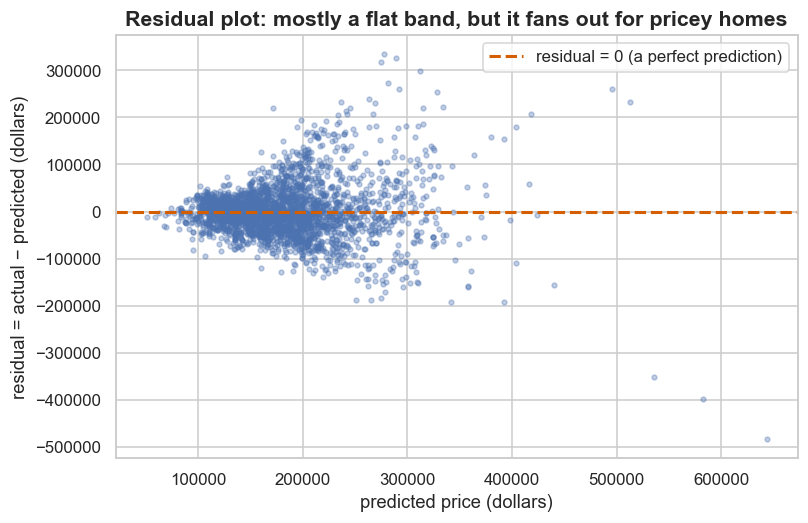

Residuals always average to ~0: mean = -0.00 dollars


In [6]:
predicted = b0 + b1 * x
residuals = y - predicted

fig, ax = plt.subplots()
ax.scatter(predicted, residuals, s=10, alpha=0.35, color='#4c72b0')
ax.axhline(0, color='#D55E00', lw=2, ls='--', label='residual = 0 (a perfect prediction)')
ax.set_xlabel('predicted price (dollars)'); ax.set_ylabel('residual = actual − predicted (dollars)')
ax.set_title('Residual plot: mostly a flat band, but it fans out for pricey homes')
ax.legend(); plt.show()

print(f'Residuals always average to ~0: mean = {residuals.mean():,.2f} dollars')

The band is roughly centered on 0 (good — the line isn't systematically too high or too low), but it
**fans out** toward expensive homes: the model's misses get larger for big houses. That's a gentle
hint the simple straight-line model is better for ordinary homes than for mansions.

### R² — the fraction of variance the line explains

How *good* is the fit, in one number? The **coefficient of determination** $R^2$ answers "what share
of the up-and-down variation in $y$ does the line account for?"

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} = \frac{\text{variance explained by the line}}{\text{total variance in } y}.$$

For a **simple** (one-predictor) regression there's a beautiful shortcut: $R^2 = r^2$, the correlation
squared. It ranges from 0 (the line explains nothing) to 1 (the line is perfect).

In [7]:
ss_res = np.sum(residuals**2)                 # leftover variation around the line
ss_tot = np.sum((y - y.mean())**2)            # total variation around the mean
R2 = 1 - ss_res / ss_tot
print(f'R^2 (from the sums of squares) = {R2:.3f}')
print(f'r squared                      = {r**2:.3f}   <- identical, as promised')
print(f'\nSo about {R2*100:.0f}% of the variation in sale price is explained by living area alone.')
print(f'The other {(1-R2)*100:.0f}% is everything else: location, quality, age, lot size, ...')

R^2 (from the sums of squares) = 0.500
r squared                      = 0.500   <- identical, as promised

So about 50% of the variation in sale price is explained by living area alone.
The other 50% is everything else: location, quality, age, lot size, ...


## 5) Prediction — and the danger of extrapolation

The whole payoff of the line is **prediction**: plug an area into $\hat{y} = b_0 + b_1 x$ and read off
an estimated price. That's safe **inside** the range of the data. Reach far **outside** it and you're
**extrapolating** — trusting the straight line in a region where you have *no evidence* it still holds.

In [8]:
def predict_price(area_sqft):
    return b0 + b1 * area_sqft

print(f'Data spans living areas from {x.min():.0f} to {x.max():.0f} sq ft.\n')
for a in [1000, 1500, 2500]:                  # <- safe: inside the observed range
    print(f'  {a:>5} sq ft  ->  predicted price ~ {predict_price(a):>12,.0f} dollars   (interpolation: OK)')

print()
for a in [50, 20000]:                          # <- reckless: far outside the data
    print(f'  {a:>5} sq ft  ->  predicted price ~ {predict_price(a):>12,.0f} dollars   (EXTRAPOLATION: do not trust)')

Data spans living areas from 334 to 5642 sq ft.

   1000 sq ft  ->  predicted price ~      124,984 dollars   (interpolation: OK)
   1500 sq ft  ->  predicted price ~      180,831 dollars   (interpolation: OK)
   2500 sq ft  ->  predicted price ~      292,525 dollars   (interpolation: OK)

     50 sq ft  ->  predicted price ~       18,874 dollars   (EXTRAPOLATION: do not trust)
  20000 sq ft  ->  predicted price ~    2,247,170 dollars   (EXTRAPOLATION: do not trust)


A 50-sq-ft "home" gets a price of about 19,000 dollars (the line is still positive there only by luck),
and a 20,000-sq-ft mansion gets a wild figure no Ames sale supports. The line knows nothing beyond the
cloud it was fit to. **Rule of thumb:** predict only within the range of $x$ you actually observed.

## 6) Correlation is **not** causation

We found a strong correlation between area and price — and here it's plausible that size really does
*drive* price. But in general, **a correlation alone never proves that one variable causes the
other.** A classic illustration with made-up-but-realistic numbers:

> Across a town's summer days, **ice-cream sales** and **drowning deaths** are strongly *positively*
> correlated. Does eating ice cream cause drowning? Of course not. A hidden third variable —
> **hot weather** — drives *both*: heat sends ice-cream sales up *and* sends more people swimming.

That hidden third variable is called a **confounder** (or **lurking variable**). Let's simulate this
exact story so you can see a strong correlation appear with **no causal link** between the two visible
variables.

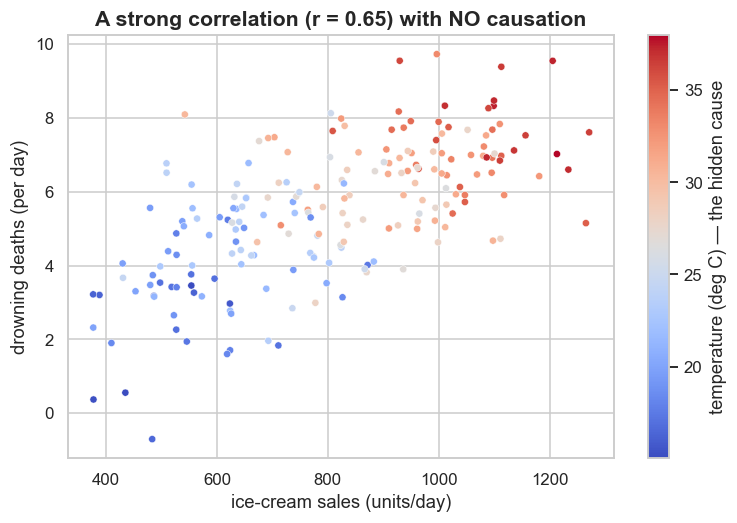

r(ice cream, drownings) = 0.65  -- strong! -- yet neither causes the other.
The colour shows the real driver: hot days (red) sit at the top-right of both.


In [9]:
rng = np.random.default_rng(3)        # change this seed to draw a different summer
n_days = 200

temperature = rng.uniform(15, 38, size=n_days)                       # the hidden confounder (deg C)
ice_cream  = 30 * temperature + rng.normal(0, 120, size=n_days)      # heat -> more ice cream
drownings  = 0.20 * temperature + rng.normal(0, 1.2, size=n_days)    # heat -> more swimming -> more drownings
# NOTE: ice_cream never appears in the drownings formula. There is NO causal link between them.

r_fake = np.corrcoef(ice_cream, drownings)[0, 1]
fig, ax = plt.subplots()
sc = ax.scatter(ice_cream, drownings, c=temperature, cmap='coolwarm', s=22, edgecolor='white', lw=0.3)
ax.set_xlabel('ice-cream sales (units/day)'); ax.set_ylabel('drowning deaths (per day)')
ax.set_title(f'A strong correlation (r = {r_fake:.2f}) with NO causation')
fig.colorbar(sc, ax=ax, label='temperature (deg C) — the hidden cause')
plt.show()
print(f'r(ice cream, drownings) = {r_fake:.2f}  -- strong! -- yet neither causes the other.')
print('The colour shows the real driver: hot days (red) sit at the top-right of both.')

The dots line up beautifully, yet by construction ice cream has **zero** effect on drownings — the
colour gives away the real cause. To earn the word *"causes"* you generally need a **randomized
experiment** (the subject of the next lesson) or very careful adjustment for confounders. Until then,
say **"is associated with."**

## 7) Simpson's paradox — the centerpiece

Now the most startling trap of all, and it's **real**, not simulated. Switch to the penguins and look
at two bill measurements: **bill length** and **bill depth** (how tall the bill is, top to bottom).

Watch what happens to the correlation when we lump all three species together versus when we look
**within** each species.

In [10]:
overall_r = penguins['bill_length_mm'].corr(penguins['bill_depth_mm'])
print(f'OVERALL correlation (all penguins together): r = {overall_r:+.3f}   <- NEGATIVE?!\n')

print('But within each species:')
for s in ['Adelie', 'Chinstrap', 'Gentoo']:
    sub = penguins[penguins['species'] == s]
    rs = sub['bill_length_mm'].corr(sub['bill_depth_mm'])
    print(f'  {s:<10} (n={len(sub):>3}): r = {rs:+.3f}   <- POSITIVE')

OVERALL correlation (all penguins together): r = -0.235   <- NEGATIVE?!

But within each species:
  Adelie     (n=151): r = +0.391   <- POSITIVE
  Chinstrap  (n= 68): r = +0.654   <- POSITIVE
  Gentoo     (n=123): r = +0.643   <- POSITIVE


Read that again. **Pooled together, longer bills go with *shallower* bills ($r<0$).** But **inside
every single species, longer bills go with *deeper* bills ($r>0$).** The trend *reverses* depending
on whether you look at the groups or the lump. That reversal is **Simpson's paradox**. The only way to
believe it is to *see* it.

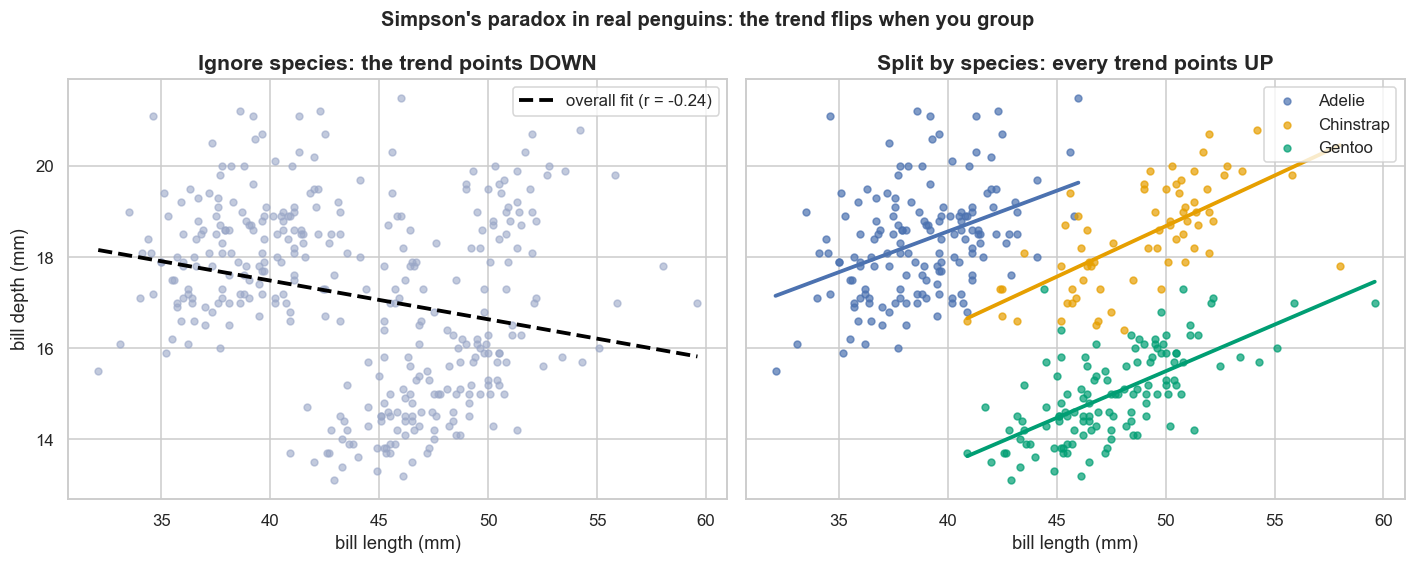

In [11]:
colors = {'Adelie': '#4c72b0', 'Chinstrap': '#E69F00', 'Gentoo': '#009E73'}

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.2), sharex=True, sharey=True)

# LEFT: ignore species. One blob, one downward line.
bx = penguins['bill_length_mm'].to_numpy(); bd = penguins['bill_depth_mm'].to_numpy()
axL.scatter(bx, bd, s=20, alpha=0.6, color='#9aa7c7')
sB, iB = np.polyfit(bx, bd, 1)
xs = np.array([bx.min(), bx.max()])
axL.plot(xs, iB + sB * xs, color='black', lw=2.5, ls='--',
         label=f'overall fit (r = {overall_r:+.2f})')
axL.set_title('Ignore species: the trend points DOWN')
axL.set_xlabel('bill length (mm)'); axL.set_ylabel('bill depth (mm)')
axL.legend(loc='upper right')

# RIGHT: colour by species, one line per group. Every line points UP.
for s in ['Adelie', 'Chinstrap', 'Gentoo']:
    sub = penguins[penguins['species'] == s]
    sx_ = sub['bill_length_mm'].to_numpy(); sy_ = sub['bill_depth_mm'].to_numpy()
    axR.scatter(sx_, sy_, s=20, alpha=0.7, color=colors[s], label=s)
    sl_, in_ = np.polyfit(sx_, sy_, 1)
    gx = np.array([sx_.min(), sx_.max()])
    axR.plot(gx, in_ + sl_ * gx, color=colors[s], lw=2.5)
axR.set_title('Split by species: every trend points UP')
axR.set_xlabel('bill length (mm)')
axR.legend(loc='upper right')

fig.suptitle("Simpson's paradox in real penguins: the trend flips when you group", fontweight='bold')
plt.tight_layout(); plt.show()

**Why does it flip?** Species is a **lurking variable** that controls *where* each cloud sits.
**Gentoo** (green) have **long, shallow** bills → **bottom-right**. **Adelie** (blue) have
**short, deep** bills → **top-left**. **Chinstrap** (orange) have **long, deep** bills →
**top-right**. The decisive gap is **Adelie (top-left) versus Gentoo (bottom-right)**: smearing the
deep-billed clouds against the shallow-billed Gentoo cloud fakes a downward trend across all three —
even though the slope **inside** each cloud points firmly up.

**The lesson:** an aggregate correlation can be the **opposite** of every subgroup correlation. Before
trusting a single $r$, ask *"is there a group variable I'm ignoring?"* This is why the species column
in Lesson 1's scatter mattered so much.

## Now you try

Predict first, then change a number and re-run:

1. **A different pair of variables.** In sections 1-4, the Ames analysis uses `area` and `price`.
   Add a cell and try a different scatter + correlation, e.g.

       fa = ames.dropna(subset=['Year.Built', 'price'])
       print(fa['Year.Built'].corr(fa['price']))

   Is the relationship stronger or weaker than area-vs-price? (Tip: `ames.columns` lists every column.)

2. **Change a prediction.** In section 5, call `predict_price(3200)` in a new cell. Is 3,200 sq ft
   inside the data range printed above (so safe), or are you extrapolating? Then try
   `predict_price(0)` and explain why the answer is exactly the intercept.

3. **Within-group vs overall, another pair.** Repeat the section-7 correlation check with
   `flipper_length_mm` and `body_mass_g` instead of the two bill measures. Compute the overall $r$ and
   the per-species $r$. Does the sign flip this time, or do the groups agree with the lump?

4. **Re-roll the confounder.** In section 6, change `np.random.default_rng(3)` to another number, or
   raise the noise from `rng.normal(0, 1.2, ...)` to `rng.normal(0, 4, ...)`. How big does the noise
   have to get before the fake ice-cream/drowning correlation stops looking convincing?

## What you learned

- A **scatterplot** is the first move for two numeric variables: read its **direction**, **form**, and
  **strength** before computing anything.
- The **correlation $r$** ($-1$ to $+1$) measures the strength and direction of a **linear** trend; it
  is **unitless** and **symmetric**, and a small $r$ means "no *straight-line* trend," not "no relationship."
- The **least-squares line** $\hat{y}=b_0+b_1x$ minimizes the squared vertical misses; its **slope**
  $b_1 = r\,s_y/s_x$ reads as "change in $y$ per one unit of $x$," and the **intercept** is often
  physically meaningless.
- **Residuals** (actual − predicted) should look like a flat, shapeless band; **$R^2 = r^2$** is the
  fraction of $y$'s variation the line explains.
- **Extrapolating** beyond the observed range of $x$ is unreliable — predict only inside the data cloud.
- **Correlation is not causation:** a hidden **confounder** (hot weather) can manufacture a strong
  correlation between two effects (ice cream, drownings) with no link between them.
- **Simpson's paradox:** an overall trend can **reverse** within subgroups — the penguins' bill
  correlation is negative pooled but positive within every species, because **species** is a lurking variable.

---

**← Previous:** [Lesson 2: Distributions: shape, skew & outliers](02-distributions-shape-outliers.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Next →:** [Lesson 4: Where data comes from: sampling & study design](04-where-data-comes-from.ipynb)

**Same idea, another way:**  [Another dataset →](03-relationships-regression~another-dataset.ipynb)  ·  [The code behind it →](03-relationships-regression~the-code.ipynb)